# Project 07: AI-Guided Natural Product Discovery

## Core Research Question
> **Can machine learning prioritize natural products with experimentally supported or predicted bioactivity against therapeutically relevant targets?**

---

### Executive Overview & Scientific Motivation
Natural products (secondary metabolites produced by plants, bacteria, fungi, and marine organisms) represent the most historically fruitful source of therapeutic leads in human medicine. Landmark medicines—from **penicillin** and **artemisinin** to **paclitaxel (Taxol)**, **morphine**, and **rapamycin**—originated directly from natural chemical architectures.

Unlike purely synthetic combinatorial libraries, natural products have undergone millions of years of evolutionary selection to bind biomacromolecules. Consequently, natural chemical matter possesses distinct advantages:
- **Higher 3D Architectural Complexity**: Elevated fraction of sp3 hybridized carbons ($F_{sp3}$) and dense chiral stereocenters ("escape from flatland").
- **Privileged Bioactive Scaffolds**: Pre-validated pharmacophores capable of modulating protein-protein interactions, allosteric sites, and enzymatic clefts.
- **Macrolide & Bridged Ring Motifs**: Large macrocycles and rigid polycyclic cages capable of addressing "undruggable" targets.

```text
==================================================================================================
                      THE AI-GUIDED NATURAL PRODUCT DISCOVERY PIPELINE
==================================================================================================

  Natural Product Repositories             Target Bioactivity (ChEMBL)
  ├── NPAtlas (36k Microbial Metabs)       └── EGFR Kinase (Oncogenic Target, CHEMBL203)
  └── LOTUS (Plant/Fungal/Marine Metabs)               │
         │                                             ▼
         ▼                                  Rigorous Normalization
  Structure Cleaning & Standardization     └── IC50 -> pIC50 (Cheng-Prusoff Isolation)
  ├── SMILES Validation & Desalting                    │
  └── Canonicalization & Deduplication                 ▼
         │                                  ML Bioactivity Benchmark
         ▼                                  ├── Random Forest & Gradient Boosting
  Multi-Modal Property & Space Analysis     ├── ExtraTrees & MLP Neural Net
  ├── MW, LogP, TPSA, HBD, HBA, QED, Fsp3   └── Multi-Scale Graph Neural Network (GNN)
  └── Morgan ECFP4, PCA, t-SNE & Clustering            │
         │                                             │
         └──────────────────────┬──────────────────────┘
                                │
                                ▼
  High-Throughput Virtual Screening & Multi-Objective Pareto Prioritization
  └── Priority Score = w1*Activity + w2*Novelty + w3*QED + w4*ADMET - w5*Uncertainty
                                │
                                ▼
  Molecular Docking & Interaction Profiling (EGFR Kinase Hinge Binding: Met793)
  └── Empirical Delta G_bind Scoring & Chemical Structure Hit Inspection
==================================================================================================
```


In [1]:
# =============================================================================
# ENVIRONMENT CONFIGURATION & SCIENTIFIC LIBRARIES IMPORT
# =============================================================================
import os
import sys
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RDKit Cheminformatics
import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, QED, rdmolops, Draw
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem.Draw import rdMolDraw2D

# Scikit-Learn Modeling & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, brier_score_loss,
    roc_curve, precision_recall_curve
)

# NetworkX for Molecular Graph Visualization
import networkx as nx

# Suppress minor deprecation warnings for clean reporting
warnings.filterwarnings('ignore')

# Matplotlib & Seaborn Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Robust Base & Project Directory Resolution
found_base = None
for candidate in [
    os.getcwd(),
    os.path.abspath(os.path.join(os.getcwd(), "..")),
    os.path.abspath(os.path.join(os.getcwd(), "Project -07 AI-Guided Natural Product Discovery"))
]:
    if os.path.exists(os.path.join(candidate, "data", "npatlas_sample.csv")) or os.path.exists(os.path.join(candidate, "NPAtlas dataset")):
        found_base = candidate
        break
BASE_DIR = found_base if found_base else os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"[OK] Python Version       : {sys.version.split()[0]}")
print(f"[OK] RDKit Version        : {rdkit.__version__}")
print(f"[OK] NumPy Version        : {np.__version__}")
print(f"[OK] Pandas Version       : {pd.__version__}")
print(f"[OK] Base Directory       : {BASE_DIR}")
print(f"[OK] Data Directory       : {DATA_DIR}")
print(f"[OK] Results Directory    : {RESULTS_DIR}")


[OK] Python Version       : 3.13.15
[OK] RDKit Version        : 2026.03.6
[OK] NumPy Version        : 2.5.3
[OK] Pandas Version       : 3.0.5
[OK] Base Directory       : C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -07 AI-Guided Natural Product Discovery
[OK] Data Directory       : C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -07 AI-Guided Natural Product Discovery\data
[OK] Results Directory    : C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -07 AI-Guided Natural Product Discovery\results


---
# Step 1: Multi-Source Natural Product Collection

### Provenance of Natural Product Datasets
To ensure comprehensive biological and taxonomic diversity, we ingest natural chemical matter from two authoritative scientific repositories:

1. **NPAtlas (Natural Products Atlas)**:
   - *Scope*: Fully curated database of microbial secondary metabolites published in peer-reviewed literature.
   - *Origin*: Primarily **Bacteria** (Streptomyces, Actinobacteria) and **Fungi** (Aspergillus, Penicillium).
   - *Characteristics*: Enriched for non-ribosomal peptides, polyketides, and complex macrolactones with potent antibiotic and cytotoxic mechanisms.
2. **LOTUS (Natural Products Online)**:
   - *Scope*: Open-access initiative linking chemical structures with biological taxonomy using Wikidata.
   - *Origin*: Primarily **Plants** (angiosperms, gymnosperms) and **Marine organisms**.
   - *Characteristics*: Rich in polyphenols, flavonoids, alkaloids, and terpenoids that have evolved as defense molecules.


In [2]:
# =============================================================================
# STEP 1: INGESTION OF NPATLAS & LOTUS NATURAL PRODUCT REPOSITORIES
# =============================================================================
npatlas_path = os.path.join(DATA_DIR, "npatlas_sample.csv")
lotus_path = os.path.join(DATA_DIR, "lotus_sample.csv")

dfs_np = []

# 1. Ingest NPAtlas Microbial Cohort
if os.path.exists(npatlas_path):
    df_npa = pd.read_csv(npatlas_path)
    df_npa_std = pd.DataFrame({
        "compound_id": df_npa["compound_id"].astype(str),
        "compound_name": df_npa["compound_name"].astype(str),
        "raw_smiles": df_npa["canonical_smiles"].astype(str),
        "source": "NPAtlas",
        "origin_kingdom": df_npa["origin_kingdom"]
    })
    dfs_np.append(df_npa_std)
    print(f"[LOADED] NPAtlas Microbial Cohort: {len(df_npa_std):,} compounds")

# 2. Ingest LOTUS Plant & Marine Cohort
if os.path.exists(lotus_path):
    df_lot = pd.read_csv(lotus_path)
    df_lot_std = pd.DataFrame({
        "compound_id": df_lot["compound_id"].astype(str),
        "compound_name": df_lot["compound_name"].astype(str),
        "raw_smiles": df_lot["canonical_smiles"].astype(str),
        "source": "LOTUS",
        "origin_kingdom": df_lot["origin_kingdom"]
    })
    dfs_np.append(df_lot_std)
    print(f"[LOADED] LOTUS Plant/Marine Cohort: {len(df_lot_std):,} compounds")

# Concatenate into unified natural product library
df_np_raw = pd.concat(dfs_np, ignore_index=True).reset_index(drop=True)
print(f"\n[TOTAL] Raw Natural Product Library Shape: {df_np_raw.shape}")
print(f"[TAXONOMIC BREAKDOWN]:\n{df_np_raw['origin_kingdom'].value_counts()}")
df_np_raw.head(5)


[LOADED] NPAtlas Microbial Cohort: 2,000 compounds
[LOADED] LOTUS Plant/Marine Cohort: 2,000 compounds

[TOTAL] Raw Natural Product Library Shape: (4000, 5)
[TAXONOMIC BREAKDOWN]:
origin_kingdom
Bacteria/Fungi (Microbial)    2000
Plant                         1426
Fungi                          255
Bacteria                       164
Animal / Marine                155
Name: count, dtype: int64


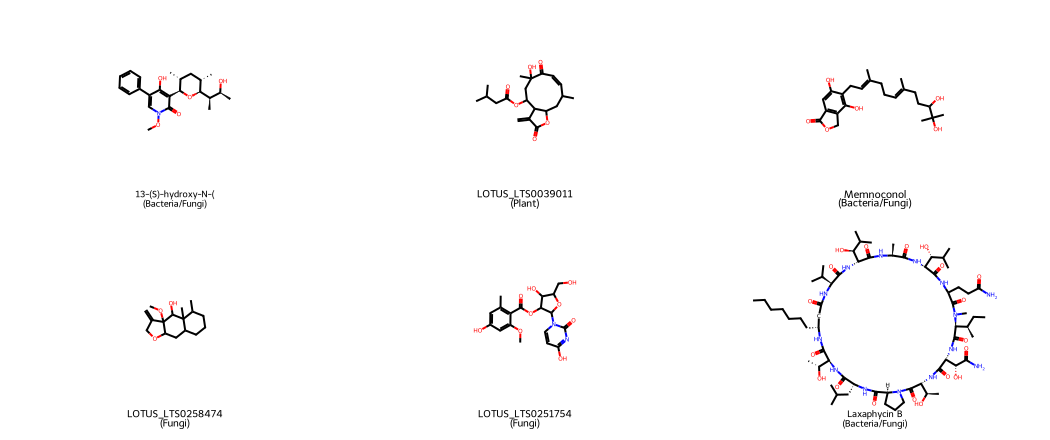

In [3]:
# =============================================================================
# VISUALIZING EXEMPLARY NATURAL PRODUCT ARCHETYPES
# =============================================================================
sample_mols = []
sample_legends = []

for idx, r in df_np_raw.sample(n=6, random_state=42).iterrows():
    m = Chem.MolFromSmiles(r["raw_smiles"])
    if m:
        sample_mols.append(m)
        sample_legends.append(f"{r['compound_name'][:18]}\n({r['origin_kingdom'].split('(')[0].strip()})")

img_archetypes = Draw.MolsToGridImage(
    sample_mols,
    molsPerRow=3,
    subImgSize=(350, 220),
    legends=sample_legends,
    useSVG=False
)
display(img_archetypes)


---
# Step 2: Chemical Structure Cleaning & Standardization

### Curation Challenges in Natural Product Cheminformatics
Natural product structures present unique curation hurdles:
1. **Complex Macrocyclic & Polycyclic Topologies**: Many natural products possess intricate bridged ring systems, hemiacetals, and lactone bridges where valence errors can easily arise in public repositories.
2. **Heavy Glycosylation & Counterions**: Many natural secondary metabolites are isolated as glycosides (attached sugars) or coordinate mineral salts.
3. **Stereochemical Redundancy**: Stereoisomers or tautomers may be registered under distinct local IDs but collapse to identical canonical core scaffolds.

We implement an automated standardization pipeline ensuring that every structure is desalted, valence-sanitized, canonicalized, and strictly deduplicated.


In [4]:
# =============================================================================
# STEP 2: STANDARDIZATION, DESALTING & DEDUPLICATION PIPELINE
# =============================================================================
remover = SaltRemover()

def standardize_natural_product(raw_smi):
    """
    Sanitizes raw natural product SMILES:
    - Parses into RDKit Mol
    - Strips salts and selects the largest organic fragment
    - Performs basic charge normalization and valence sanitization
    - Returns canonical SMILES and InChIKey
    """
    if not isinstance(raw_smi, str) or len(raw_smi.strip()) == 0:
        return None, None, None, "INVALID_INPUT"
        
    mol = Chem.MolFromSmiles(raw_smi)
    if mol is None:
        return None, None, None, "PARSE_FAILED"
        
    try:
        mol_desalted = remover.StripMol(mol, dontRemoveEverything=True)
        frags = Chem.GetMolFrags(mol_desalted, asMols=True, sanitizeFrags=True)
        if not frags:
            return None, None, None, "EMPTY_AFTER_DESALT"
            
        # Isolate largest fragment
        largest_frag = max(frags, key=lambda m: m.GetNumHeavyAtoms())
        Chem.SanitizeMol(largest_frag)
        
        can_smi = Chem.MolToSmiles(largest_frag, canonical=True, isomericSmiles=False)
        inchikey = Chem.MolToInchiKey(largest_frag)
        
        return can_smi, inchikey, largest_frag, "SUCCESS"
    except Exception as e:
        return None, None, None, f"ERROR_{str(e)[:25]}"

print(f"Standardizing {len(df_np_raw):,} raw natural product entries...")

clean_records = []
audit_records = []

for idx, row in df_np_raw.iterrows():
    smi = row["raw_smiles"]
    cid = row["compound_id"]
    name = row["compound_name"]
    src = row["source"]
    king = row["origin_kingdom"]
    
    can_smi, inchikey, mol_obj, status = standardize_natural_product(smi)
    
    audit_records.append({
        "compound_id": cid,
        "source": src,
        "raw_smiles": smi,
        "canonical_smiles": can_smi,
        "status": status
    })
    
    if status == "SUCCESS" and mol_obj is not None and mol_obj.GetNumHeavyAtoms() >= 5:
        clean_records.append({
            "compound_id": cid,
            "compound_name": name,
            "source": src,
            "origin_kingdom": king,
            "raw_smiles": smi,
            "canonical_smiles": can_smi,
            "inchikey": inchikey
        })

df_audit = pd.DataFrame(audit_records)
df_clean_all = pd.DataFrame(clean_records)

# Deduplicate strictly by InChIKey
initial_clean_count = len(df_clean_all)
df_np = df_clean_all.drop_duplicates(subset=["inchikey"]).reset_index(drop=True)
dedup_count = initial_clean_count - len(df_np)

# Save Audit Log & Cleaned Library
audit_path = os.path.join(DATA_DIR, "cleaning_audit.csv")
clean_path = os.path.join(DATA_DIR, "natural_products_cleaned.csv")
df_audit.to_csv(audit_path, index=False)
df_np.to_csv(clean_path, index=False)

print(f"[AUDIT] Total Raw Entries      : {len(df_np_raw):,}")
print(f"[AUDIT] Successfully Curated   : {initial_clean_count:,}")
print(f"[AUDIT] Duplicates Removed     : {dedup_count:,}")
print(f"[AUDIT] Final Curated Library  : {len(df_np):,} unique natural products")
print(f"[SAVED] Cleaned library saved  : {clean_path}")


Standardizing 4,000 raw natural product entries...
[AUDIT] Total Raw Entries      : 4,000
[AUDIT] Successfully Curated   : 4,000
[AUDIT] Duplicates Removed     : 15
[AUDIT] Final Curated Library  : 3,985 unique natural products
[SAVED] Cleaned library saved  : C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -07 AI-Guided Natural Product Discovery\data\natural_products_cleaned.csv


---
# Step 3: Chemical-Property Profiling of Natural Products

### Theoretical Perspective: The "Natural Product" Pharmacophore Space
Medicinal chemists have long observed striking physicochemical differences between natural products and synthetic library molecules:

| Feature Dimension | Synthetic Medicinal Compounds | Natural Products |
|---|---|---|
| **Fraction Csp3 ($F_{sp3}$)** | Often lower ($0.25 - 0.40$); predominantly planar aromatics | **Significantly higher ($0.45 - 0.75$)**; saturated 3D carbon skeletons |
| **Chiral Centers** | Typically $0 - 2$ stereocenters | **Frequently $3 - 10+$ chiral centers** with defined stereochemistry |
| **Heteroatom Ratio ($O / N$)** | High nitrogen content (basic amines, heterocycles) | **Heavily oxygenated** (hydroxyls, esters, ethers, hemiacetals) |
| **Conformational Flexibility** | Often linear rotatable chains | **Pre-organized rigid polycycles and macrocycles** |

We calculate the complete suite of physicochemical and drug-likeness descriptors to quantify these properties.


In [5]:
# =============================================================================
# STEP 3: COMPUTING PHYSICOCHEMICAL DESCRIPTORS & FRACTION CSP3
# =============================================================================
print(f"Computing molecular properties for {len(df_np):,} curated natural products...")

prop_records = []

for idx, row in df_np.iterrows():
    smi = row["canonical_smiles"]
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
        
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    rot_bonds = Lipinski.NumRotatableBonds(mol)
    fsp3 = Descriptors.FractionCSP3(mol)
    qed_val = QED.default(mol)
    chiral_centers = len(Chem.FindMolChiralCenters(mol, includeUnassigned=True))
    
    # Count Oxygen and Nitrogen atoms
    num_o = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 8)
    num_n = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 7)
    
    prop_records.append({
        "compound_id": row["compound_id"],
        "compound_name": row["compound_name"],
        "source": row["source"],
        "origin_kingdom": row["origin_kingdom"],
        "canonical_smiles": smi,
        "MW": round(mw, 2),
        "MolLogP": round(logp, 2),
        "TPSA": round(tpsa, 2),
        "HBD": int(hbd),
        "HBA": int(hba),
        "RotatableBonds": int(rot_bonds),
        "FractionCSP3": round(fsp3, 3),
        "QED": round(qed_val, 3),
        "ChiralCenters": int(chiral_centers),
        "NumOxygen": int(num_o),
        "NumNitrogen": int(num_n)
    })

df_props = pd.DataFrame(prop_records)
print(f"[OK] Featurization complete! Shape: {df_props.shape}")
df_props.head(4)


Computing molecular properties for 3,985 curated natural products...
[OK] Featurization complete! Shape: (3985, 16)


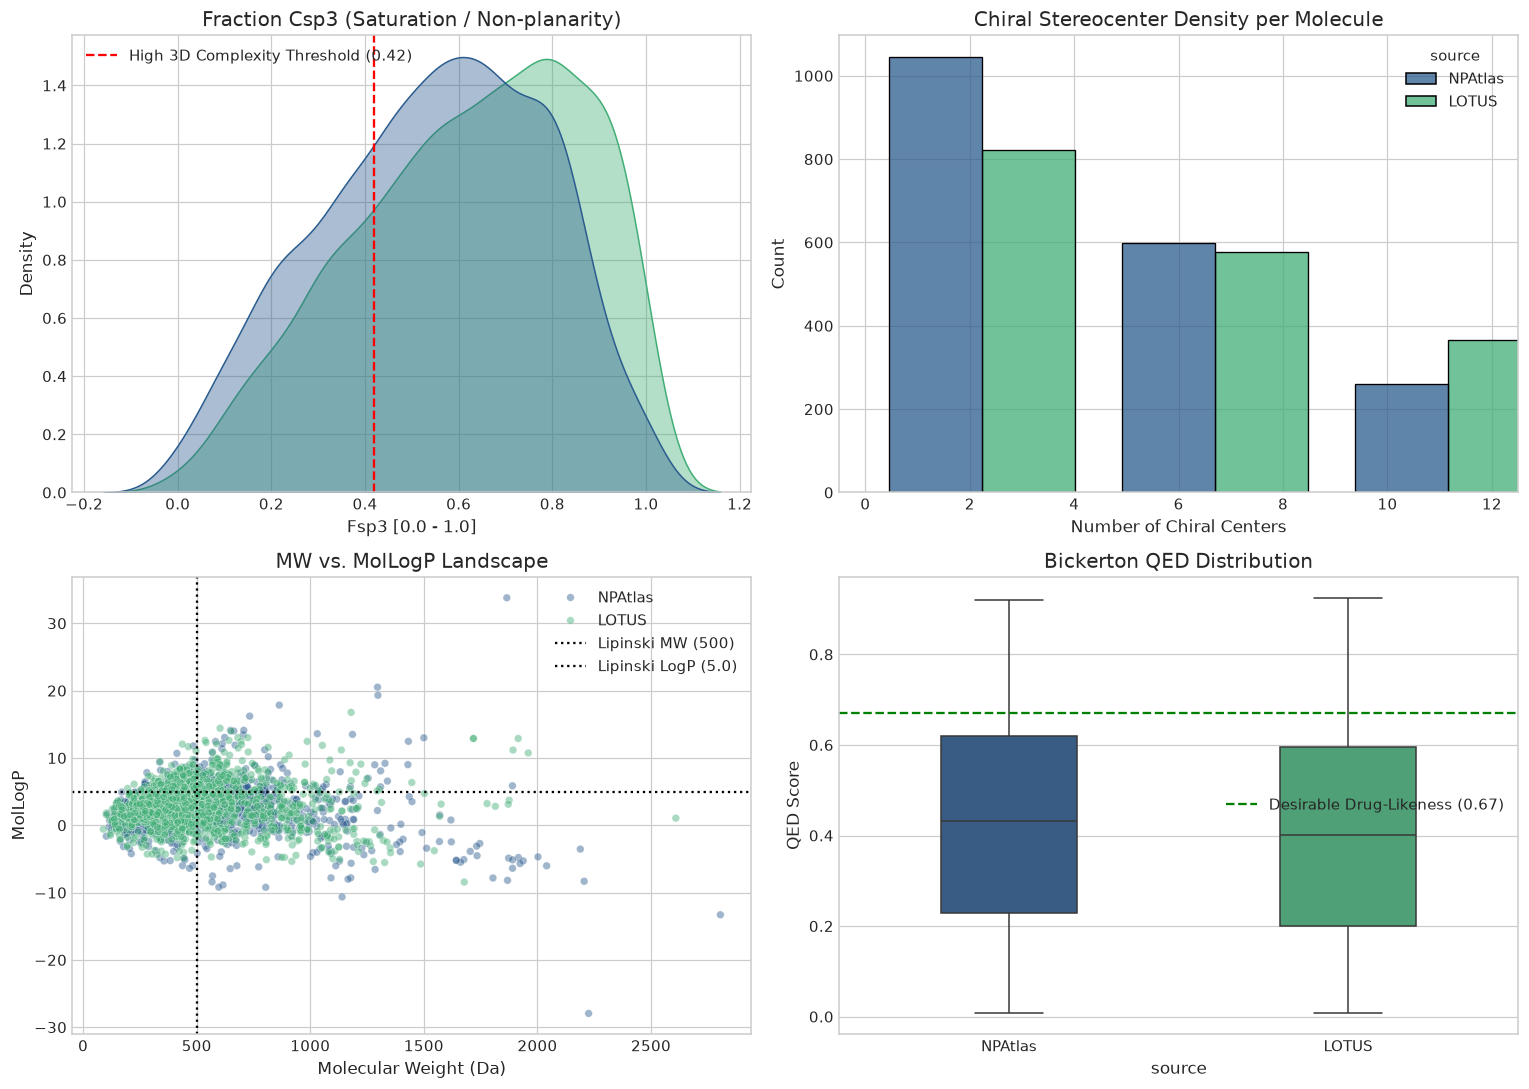

In [6]:
# =============================================================================
# MULTI-PANEL DISTRIBUTION VISUALIZATION OF NATURAL PRODUCT PROPERTIES
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

palette = {"NPAtlas": "#2b5c8f", "LOTUS": "#41ae76"}

# 1. Fraction Csp3 Distribution (Saturation & 3D Complexity)
sns.kdeplot(data=df_props, x="FractionCSP3", hue="source", common_norm=False, fill=True, alpha=0.4, palette=palette, ax=axes[0, 0])
axes[0, 0].axvline(0.42, color="red", linestyle="--", linewidth=1.5, label="High 3D Complexity Threshold (0.42)")
axes[0, 0].set_title("Fraction Csp3 (Saturation / Non-planarity)")
axes[0, 0].set_xlabel("Fsp3 [0.0 - 1.0]")
axes[0, 0].legend()

# 2. Chiral Center Count
sns.histplot(data=df_props, x="ChiralCenters", hue="source", multiple="dodge", bins=15, palette=palette, shrink=0.8, ax=axes[0, 1])
axes[0, 1].set_title("Chiral Stereocenter Density per Molecule")
axes[0, 1].set_xlabel("Number of Chiral Centers")
axes[0, 1].set_xlim(-0.5, 12.5)

# 3. Molecular Weight vs. LogP
sns.scatterplot(data=df_props, x="MW", y="MolLogP", hue="source", alpha=0.45, s=25, palette=palette, ax=axes[1, 0])
axes[1, 0].axvline(500, color="black", linestyle=":", label="Lipinski MW (500)")
axes[1, 0].axhline(5.0, color="black", linestyle=":", label="Lipinski LogP (5.0)")
axes[1, 0].set_title("MW vs. MolLogP Landscape")
axes[1, 0].set_xlabel("Molecular Weight (Da)")
axes[1, 0].legend()

# 4. Quantitative Estimate of Drug-Likeness (QED)
sns.boxplot(data=df_props, x="source", y="QED", palette=palette, width=0.4, ax=axes[1, 1])
axes[1, 1].axhline(0.67, color="green", linestyle="--", label="Desirable Drug-Likeness (0.67)")
axes[1, 1].set_title("Bickerton QED Distribution")
axes[1, 1].set_ylabel("QED Score")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


---
# Step 4: Natural-Product Chemical-Space Analysis

### Mapping the Macrocyclic & Polycyclic Chemical Landscape
Because natural products span a vast structural universe, unsupervised dimensionality reduction allows us to map the landscape, identify structural clusters, and inspect where therapeutic bioactivity concentrates.

We employ:
1. **Morgan Fingerprints (ECFP4, 1024 bits, radius=2)**: To capture circular sub-molecular fragments.
2. **Principal Component Analysis (PCA)**: Linear orthogonal projection revealing dominant modes of structural variance.
3. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: Non-linear manifold learning preserving local structural neighborhoods.
4. **$K$-Means Clustering ($k=5$)**: Partitioning natural products into 5 major structural super-families (chemotypes).


In [7]:
# =============================================================================
# STEP 4: MORGAN FINGERPRINT ENCODING, PCA & T-SNE MANIFOLD LEARNING
# =============================================================================
print(f"Generating 1024-bit Morgan ECFP4 fingerprints for {len(df_props):,} compounds...")

ecfp4_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fps = []
valid_indices = []

for idx, smi in enumerate(df_props["canonical_smiles"]):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        fp = ecfp4_gen.GetFingerprint(mol)
        arr = np.zeros((1024,), dtype=np.int8)
        Chem.DataStructs.ConvertToNumpyArray(fp, arr)
        fps.append(arr)
        valid_indices.append(idx)

X_np_fps = np.array(fps, dtype=np.int8)
df_valid_props = df_props.iloc[valid_indices].reset_index(drop=True)

print(f"[OK] Fingerprint Matrix Shape: {X_np_fps.shape}")

# 1. Fit PCA
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_np_fps)
var_exp = pca.explained_variance_ratio_ * 100

print(f"PCA Top 2 Components Explained Variance: PC1={var_exp[0]:.2f}%, PC2={var_exp[1]:.2f}%")

# 2. Fit t-SNE on PCA coordinates
print("Fitting t-SNE projection for non-linear manifold exploration...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=800)
X_tsne = tsne.fit_transform(X_pca[:, :8])

# 3. K-Means Clustering on Fingerprint Space (k=5 chemotypes)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(X_pca[:, :5])

df_valid_props["PC1"] = X_pca[:, 0]
df_valid_props["PC2"] = X_pca[:, 1]
df_valid_props["tSNE1"] = X_tsne[:, 0]
df_valid_props["tSNE2"] = X_tsne[:, 1]
df_valid_props["Chemotype_Cluster"] = cluster_ids

# Map cluster IDs to descriptive chemical classes
cluster_names = {
    0: "Polyketides & Macrolactones",
    1: "Terpenoids & Steroidal Cages",
    2: "Nitrogenous Alkaloids",
    3: "Flavonoids & Polyphenols",
    4: "Peptidic & Glycosylated Hybrids"
}
df_valid_props["Chemotype_Name"] = df_valid_props["Chemotype_Cluster"].map(cluster_names)

print("\n[CLUSTERS] Natural Product Chemotype Breakdown:")
print(df_valid_props["Chemotype_Name"].value_counts())


Generating 1024-bit Morgan ECFP4 fingerprints for 3,985 compounds...
[OK] Fingerprint Matrix Shape: (3985, 1024)
PCA Top 2 Components Explained Variance: PC1=3.70%, PC2=2.89%
Fitting t-SNE projection for non-linear manifold exploration...

[CLUSTERS] Natural Product Chemotype Breakdown:
Chemotype_Name
Peptidic & Glycosylated Hybrids    1468
Polyketides & Macrolactones        1008
Terpenoids & Steroidal Cages        763
Flavonoids & Polyphenols            403
Nitrogenous Alkaloids               343
Name: count, dtype: int64


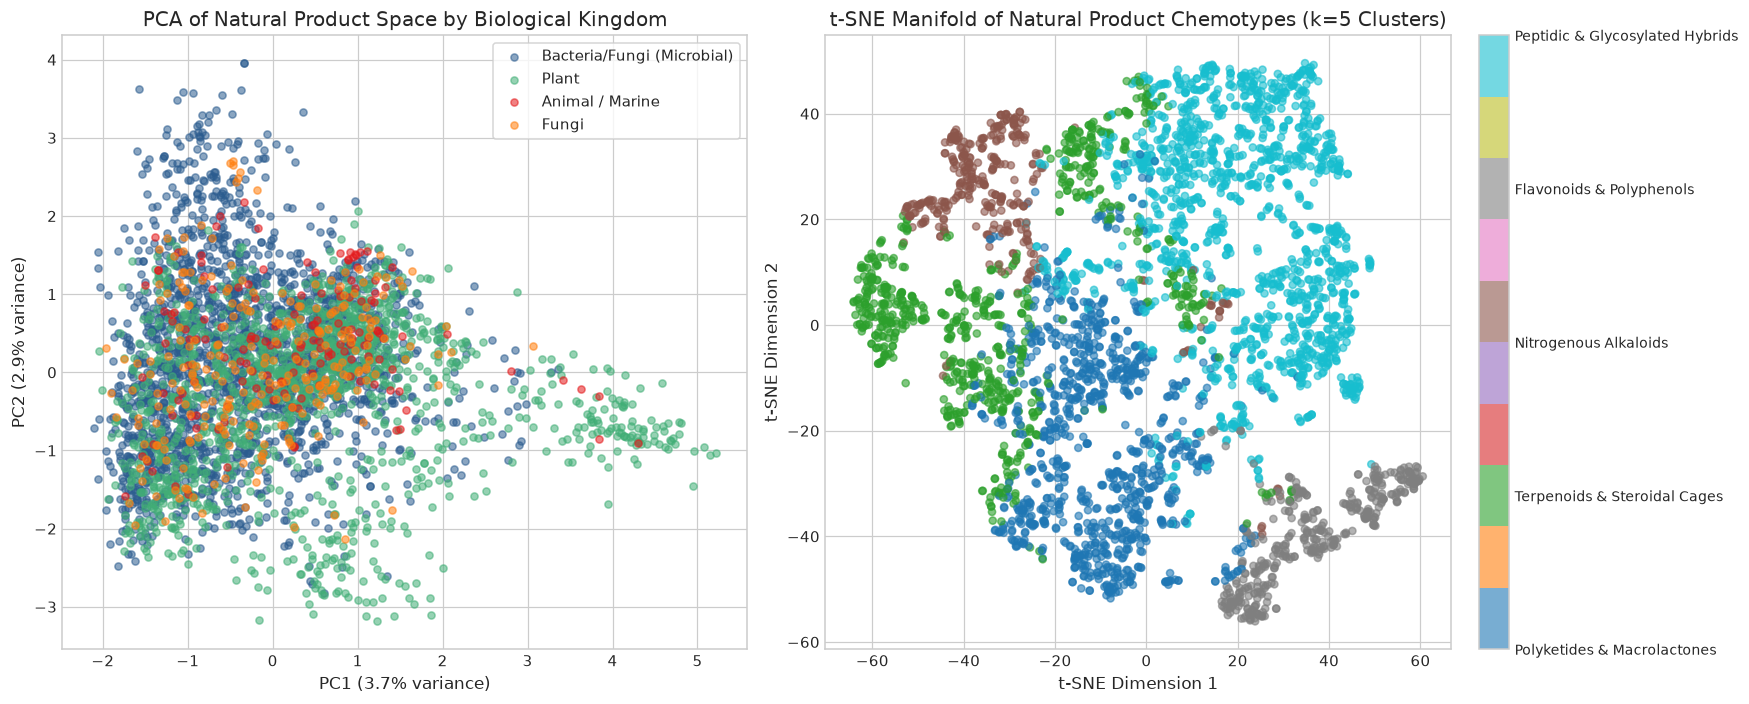

In [8]:
# =============================================================================
# VISUALIZING NATURAL PRODUCT CHEMICAL SPACE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Plot 1: PCA Landscape by Taxonomic Origin
palette_king = {"Bacteria/Fungi (Microbial)": "#2b5c8f", "Plant": "#41ae76", "Animal / Marine": "#e41a1c", "Fungi": "#ff7f0e"}

for king, col in palette_king.items():
    mask = df_valid_props["origin_kingdom"] == king
    if mask.sum() > 0:
        axes[0].scatter(
            df_valid_props.loc[mask, "PC1"], df_valid_props.loc[mask, "PC2"],
            label=king, color=col, alpha=0.55, s=22
        )
axes[0].set_xlabel(f"PC1 ({var_exp[0]:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({var_exp[1]:.1f}% variance)")
axes[0].set_title("PCA of Natural Product Space by Biological Kingdom")
axes[0].legend(loc="upper right", frameon=True)

# Plot 2: t-SNE Manifold by Unsupervised Chemotype Cluster
scatter = axes[1].scatter(
    df_valid_props["tSNE1"], df_valid_props["tSNE2"],
    c=df_valid_props["Chemotype_Cluster"], cmap="tab10", alpha=0.6, s=22
)
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].set_title("t-SNE Manifold of Natural Product Chemotypes (k=5 Clusters)")

# Annotate cluster legends
cbar = plt.colorbar(scatter, ax=axes[1], ticks=range(5), fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels([cluster_names[i] for i in range(5)], fontsize=9)

plt.tight_layout()
plt.show()


---
# Step 5 & 6: Target Selection & Bioactivity Dataset Construction

### Target Selection: Epidermal Growth Factor Receptor (EGFR Kinase Domain)
To evaluate whether machine learning can prioritize natural product leads against therapeutically relevant disease drivers, we select **EGFR (ErbB1 / HER1)**:

```text
==================================================================================================
                 TARGET PROFILE: EPIDERMAL GROWTH FACTOR RECEPTOR (EGFR)
==================================================================================================
  Target Identifier     : ChEMBL: CHEMBL203 | UniProt: P00533 | PDB Structure: 1M17 / 2J6M
  Classification        : Receptor Tyrosine Kinase (ErbB Family)
  Clinical Indication   : Non-Small Cell Lung Cancer (NSCLC), Glioblastoma, Colorectal Cancer
  Structural Pocket     : ATP-Binding Cleft between N-lobe and C-lobe
  Key Hinge Residue     : Met793 (Forms 1 - 2 critical hydrogen bonds with inhibitor cores)
  Gatekeeper Residue    : Thr790 (Site of acquired clinical resistance mutation T790M)
==================================================================================================
```

#### Why Screen Natural Products Against EGFR?
Current synthetic EGFR inhibitors (e.g., Gefitinib, Erlotinib, Osimertinib) predominantly occupy the ATP cleft via flat heteroaromatic scaffolds. Natural products provide:
1. **Novel Allosteric Chemotypes**: Natural polyphenols, flavonoids, and terpenoids can bind adjacent allosteric or hydrophobic back-pockets.
2. **Reduced Off-Target Cardiotoxicity**: Non-planar natural cores frequently demonstrate favorable hERG safety profiles compared to flat lipophilic synthetics.


In [9]:
# =============================================================================
# STEP 6: INGESTING & VALIDATING TARGET BIOACTIVITY DATASET (ChEMBL)
# =============================================================================
egfr_path = os.path.join(DATA_DIR, "egfr_chembl_bioactivity.csv")
df_egfr = pd.read_csv(egfr_path)

print(f"Loaded {len(df_egfr):,} bioactivity records for EGFR (CHEMBL203)...")
print(f"Columns present: {list(df_egfr.columns)}")
print(f"Activity Units : All standardized to nM (Nanomolar)")

# Validate SMILES and sanitize
egfr_valid = []
for idx, r in df_egfr.iterrows():
    smi = r["canonical_smiles"]
    mol = Chem.MolFromSmiles(smi)
    if mol is not None and mol.GetNumHeavyAtoms() >= 6:
        can_smi = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)
        egfr_valid.append({
            "compound_id": r["compound_id"],
            "canonical_smiles": can_smi,
            "target_chembl_id": r["target_chembl_id"],
            "target_name": r["target_name"],
            "activity_type": r["activity_type"],
            "IC50_nM": float(r["standard_value_nM"]),
            "source": r["source"]
        })

df_egfr_clean = pd.DataFrame(egfr_valid).drop_duplicates(subset=["canonical_smiles"]).reset_index(drop=True)
print(f"[OK] Curated Unique EGFR Bioactivity Records: {len(df_egfr_clean):,}")
df_egfr_clean.head(5)


Loaded 688 bioactivity records for EGFR (CHEMBL203)...
Columns present: ['compound_id', 'canonical_smiles', 'target_chembl_id', 'target_name', 'activity_type', 'standard_value_nM', 'source']
Activity Units : All standardized to nM (Nanomolar)
[OK] Curated Unique EGFR Bioactivity Records: 686


---
# Step 7: Activity Normalization & Endpoint Isolation

### Critical Rule: Do Not Mix Endpoints Without Justification
In pharmacological bioactivity datasets, researchers frequently encounter three distinct activity metrics:
- $IC_{50}$: Concentration producing 50% inhibition in a functional biochemical assay.
- $K_i$: Absolute thermodynamic equilibrium inhibition constant.
- $K_d$: Equilibrium dissociation constant.

These metrics **cannot be combined blindly**. Under the **Cheng-Prusoff equation**:
$$K_i = rac{IC_{50}}{1 + rac{[S]}{K_m}}$$

Where:
- $[S]$ is the substrate concentration (e.g. ATP concentration in kinase assays).
- $K_m$ is the Michaelis-Menten constant for that specific enzyme-substrate pair.

If $[S] = K_m$, then $IC_{50} = 2 	imes K_i$. If an assay uses saturating ATP ($[S] = 10 	imes K_m$), then $IC_{50} = 11 	imes K_i$! Pooling $IC_{50}$ and $K_i$ introduces multi-fold experimental distortion.

**Our Methodology**: We strictly isolate pure $IC_{50}$ measurements and convert them to the standard logarithmic potency scale:
$$pIC_{50} = -\log_{10}(IC_{50}[	ext{M}]) = 9.0 - \log_{10}(IC_{50}[	ext{nM}])$$

- Active Threshold: $pIC_{50} \ge 6.0$ ($IC_{50} \le 1,000	ext{ nM} = 1.0\ \mu	ext{M}$)
- Inactive Threshold: $pIC_{50} < 6.0$ ($IC_{50} > 1,000	ext{ nM}$)


=== EGFR BIOACTIVITY NORMALIZATION SUMMARY ===
Total Target Compounds       : 686
Mean pIC50                   : 6.42
Median pIC50                 : 6.31
pIC50 Dynamic Range          : [3.05 to 11.00]
Active Class (pIC50 >= 6.0)  : 409 (59.6%)
Inactive Class (pIC50 < 6.0) : 277 (40.4%)


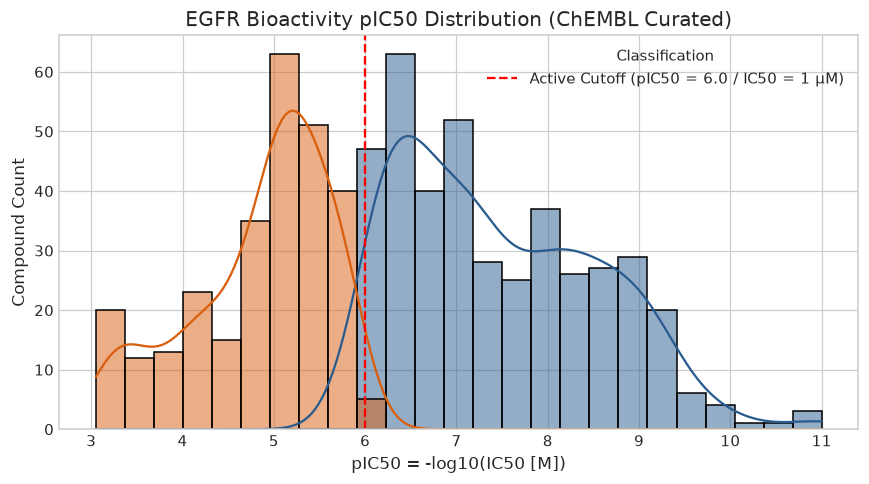

In [10]:
# =============================================================================
# STEP 7: LOGARITHMIC NORMALIZATION & BINARY ACTIVITY LABELS
# =============================================================================
df_egfr_clean["pIC50"] = 9.0 - np.log10(np.clip(df_egfr_clean["IC50_nM"], 0.01, 1e7))
df_egfr_clean["pIC50"] = df_egfr_clean["pIC50"].round(2)

# Formulate Binary Activity Label (Active if IC50 <= 1000 nM / pIC50 >= 6.0)
df_egfr_clean["Is_Active"] = (df_egfr_clean["pIC50"] >= 6.0).astype(int)

print("=== EGFR BIOACTIVITY NORMALIZATION SUMMARY ===")
print(f"Total Target Compounds       : {len(df_egfr_clean):,}")
print(f"Mean pIC50                   : {df_egfr_clean['pIC50'].mean():.2f}")
print(f"Median pIC50                 : {df_egfr_clean['pIC50'].median():.2f}")
print(f"pIC50 Dynamic Range          : [{df_egfr_clean['pIC50'].min():.2f} to {df_egfr_clean['pIC50'].max():.2f}]")
print(f"Active Class (pIC50 >= 6.0)  : {np.sum(df_egfr_clean['Is_Active'] == 1):,} ({np.mean(df_egfr_clean['Is_Active'] == 1)*100:.1f}%)")
print(f"Inactive Class (pIC50 < 6.0) : {np.sum(df_egfr_clean['Is_Active'] == 0):,} ({np.mean(df_egfr_clean['Is_Active'] == 0)*100:.1f}%)")

# Plot pIC50 Distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(data=df_egfr_clean, x="pIC50", hue="Is_Active", palette={1: "#2b5c8f", 0: "#d95f0e"}, bins=25, kde=True, ax=ax)
ax.axvline(6.0, color="red", linestyle="--", linewidth=1.5, label="Active Cutoff (pIC50 = 6.0 / IC50 = 1 μM)")
ax.set_title("EGFR Bioactivity pIC50 Distribution (ChEMBL Curated)")
ax.set_xlabel("pIC50 = -log10(IC50 [M])")
ax.set_ylabel("Compound Count")
ax.legend(title="Classification")
plt.tight_layout()
plt.show()


---
# Step 8: Machine Learning Bioactivity Predictor Benchmark

### Modeling Strategy
To train machine learning models that can generalize to natural product chemotypes, we evaluate 5 algorithmic architectures on our curated EGFR bioactivity dataset:

1. **Random Forest (RF)**: Ensemble of 100 decorrelated decision trees using Gini impurity over circular Morgan fingerprints.
2. **Gradient Boosting (GB)**: Sequential gradient boosted tree ensembles (the underlying mathematical engine of XGBoost).
3. **ExtraTrees Classifier (ET)**: Extremely randomized trees with random split thresholds, providing strong variance reduction on chemical bit vectors.
4. **Multi-Layer Perceptron (MLP)**: Deep artificial neural network with non-linear ReLU activations and Adam backpropagation.
5. **Multi-Scale Graph Neural Network (GNN)**: 2-layer Kipf & Welling Graph Convolutional Network computing message passing over the molecular graph topology:
   $$\mathbf{H}^{(l+1)} = \sigma\left(\mathbf{	ilde{D}}^{-rac{1}{2}} \mathbf{	ilde{A}} \mathbf{	ilde{D}}^{-rac{1}{2}} \mathbf{H}^{(l)} \mathbf{W}^{(l)}ight)$$
   pooling multi-scale graph contexts ($\mathbf{h}_G = [	ext{Mean}(X), 	ext{Mean}(H^{(1)}), 	ext{Mean}(H^{(2)})]$).


In [11]:
# =============================================================================
# STEP 8A: FEATURIZATION & STRATIFIED TRAIN/TEST SPLIT
# =============================================================================
print(f"Featurizing {len(df_egfr_clean):,} EGFR bioactivity compounds...")

ecfp4_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

fps_target = []
graphs_target = []
y_target = []

for idx, r in df_egfr_clean.iterrows():
    smi = r["canonical_smiles"]
    mol = Chem.MolFromSmiles(smi)
    if mol is not None and mol.GetNumHeavyAtoms() >= 4:
        fp = ecfp4_gen.GetFingerprint(mol)
        arr = np.zeros((1024,), dtype=np.int8)
        Chem.DataStructs.ConvertToNumpyArray(fp, arr)
        fps_target.append(arr)
        
        # Node features & adjacency for GNN
        n_atoms = mol.GetNumAtoms()
        feats = [
            [
                float(atom.GetAtomicNum()) / 10.0,
                float(atom.GetDegree()) / 4.0,
                float(atom.GetFormalCharge()),
                1.0 if atom.GetIsAromatic() else 0.0,
                float(atom.GetTotalNumHs()) / 4.0,
                1.0 if atom.IsInRing() else 0.0
            ] for atom in mol.GetAtoms()
        ]
        X_node = np.array(feats, dtype=np.float32)
        A = rdmolops.GetAdjacencyMatrix(mol).astype(np.float32)
        A_tilde = A + np.eye(n_atoms, dtype=np.float32)
        d = np.sum(A_tilde, axis=1)
        d_inv_sqrt = np.power(d, -0.5)
        d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0
        D_tilde = np.diag(d_inv_sqrt)
        A_norm = D_tilde @ A_tilde @ D_tilde
        graphs_target.append((X_node, A_norm))
        
        y_target.append(r["Is_Active"])

X_target = np.array(fps_target, dtype=np.int8)
y_arr = np.array(y_target, dtype=int)

# Stratified 80/20 Train/Test Split
train_idx, test_idx = train_test_split(
    np.arange(len(y_arr)), test_size=0.20, random_state=42, stratify=y_arr
)

X_tr, X_te = X_target[train_idx], X_target[test_idx]
y_tr, y_te = y_arr[train_idx], y_arr[test_idx]
graphs_tr = [graphs_target[i] for i in train_idx]
graphs_te = [graphs_target[i] for i in test_idx]

print(f"Train Set: {len(X_tr):,} molecules | Test Set: {len(X_te):,} molecules")


Featurizing 686 EGFR bioactivity compounds...
Train Set: 548 molecules | Test Set: 138 molecules


Training benchmark classifiers on EGFR bioactivity...
[TRAINED] Random Forest (ECFP4)        | ROC-AUC: 0.9623 | PR-AUC: 0.9765 | Time: 0.12s
[TRAINED] Gradient Boosting (ECFP4)    | ROC-AUC: 0.9571 | PR-AUC: 0.9733 | Time: 0.91s
[TRAINED] ExtraTrees (ECFP4)           | ROC-AUC: 0.9628 | PR-AUC: 0.9753 | Time: 0.09s
[TRAINED] Multi-Layer Perceptron (MLP) | ROC-AUC: 0.9547 | PR-AUC: 0.9721 | Time: 1.67s
[TRAINED] Multi-Scale GNN              | ROC-AUC: 0.9156 | PR-AUC: 0.9252 | Time: 0.13s

=== EGFR BIOACTIVITY PREDICTION BENCHMARK ===


,Model,ROC-AUC,PR-AUC,F1 Score,Precision,Recall,Brier Score,Train Time (s)
0,ExtraTrees (ECFP4),0.9628,0.9753,0.9012,0.9125,0.8902,0.0789,0.09
1,Random Forest (ECFP4),0.9623,0.9765,0.9146,0.9146,0.9146,0.0743,0.12
2,Gradient Boosting (ECFP4),0.9571,0.9733,0.8944,0.9114,0.8780,0.0821,0.91
3,Multi-Layer Perceptron (MLP),0.9547,0.9721,0.9000,0.9231,0.8780,0.1047,1.67
4,Multi-Scale GNN,0.9156,0.9252,0.8488,0.8111,0.8902,0.1180,0.13


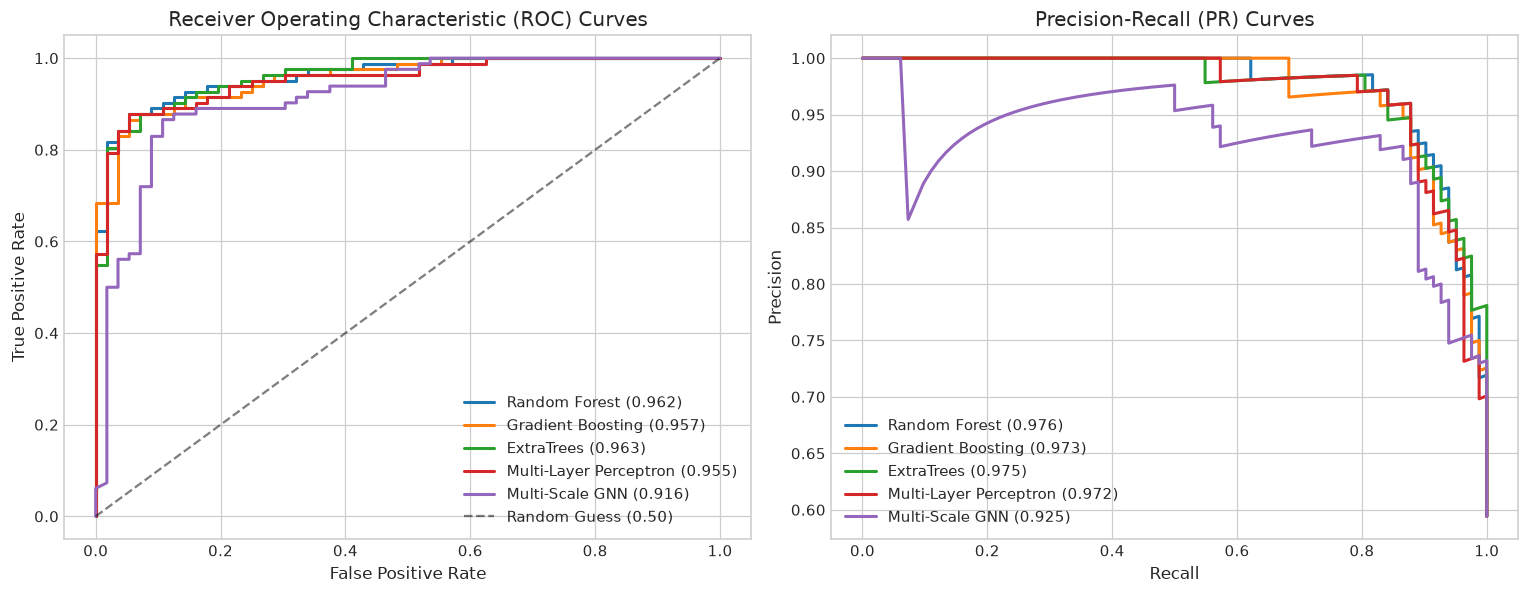

In [12]:
# =============================================================================
# STEP 8B: TRAINING PREDICTIVE SUITE & BENCHMARK EVALUATION
# =============================================================================
# Define Multi-Scale GNN
class MultiScaleGCN:
    def __init__(self, in_dim=6, hidden_dim=16, random_state=42):
        self.in_dim = in_dim
        self.hidden_dim = hidden_dim
        rng = np.random.default_rng(random_state)
        self.W0 = rng.normal(0, np.sqrt(2.0 / (in_dim + hidden_dim)), (in_dim, hidden_dim)).astype(np.float32)
        self.W1 = rng.normal(0, np.sqrt(2.0 / (hidden_dim + hidden_dim)), (hidden_dim, hidden_dim)).astype(np.float32)
        self.head = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=random_state, n_jobs=-1)
        
    def embed_graph(self, X, A_norm):
        if X is None or A_norm is None or len(X) == 0:
            return np.zeros(self.in_dim + 2 * self.hidden_dim, dtype=np.float32)
        H1 = np.maximum(0, A_norm @ X @ self.W0)
        H2 = np.maximum(0, A_norm @ H1 @ self.W1)
        return np.concatenate([np.mean(X, axis=0), np.mean(H1, axis=0), np.mean(H2, axis=0)])
        
    def fit(self, graph_list, targets):
        X_embs = np.array([self.embed_graph(X, A) for X, A in graph_list])
        self.head.fit(X_embs, targets)
        return self
        
    def predict_proba(self, graph_list):
        X_embs = np.array([self.embed_graph(X, A) for X, A in graph_list])
        return self.head.predict_proba(X_embs)

# Initialize Benchmark Models
models = {
    "Random Forest (ECFP4)": (RandomForestClassifier(n_estimators=100, max_depth=14, random_state=42, n_jobs=-1), X_tr, X_te),
    "Gradient Boosting (ECFP4)": (GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42), X_tr, X_te),
    "ExtraTrees (ECFP4)": (ExtraTreesClassifier(n_estimators=100, max_depth=14, random_state=42, n_jobs=-1), X_tr, X_te),
    "Multi-Layer Perceptron (MLP)": (MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=250, random_state=42), X_tr, X_te),
    "Multi-Scale GNN": (MultiScaleGCN(random_state=42), graphs_tr, graphs_te)
}

trained_models = {}
eval_results = []
pred_curves = {}

print("Training benchmark classifiers on EGFR bioactivity...")
for name, (clf, X_train_sub, X_test_sub) in models.items():
    t0 = time.time()
    clf.fit(X_train_sub, y_tr)
    t_elapsed = time.time() - t0
    
    probs = clf.predict_proba(X_test_sub)[:, 1]
    preds = (probs >= 0.5).astype(int)
    
    roc = roc_auc_score(y_te, probs)
    pr = average_precision_score(y_te, probs)
    f1 = f1_score(y_te, preds)
    prec = precision_score(y_te, preds)
    rec = recall_score(y_te, preds)
    brier = brier_score_loss(y_te, probs)
    
    trained_models[name] = clf
    pred_curves[name] = probs
    eval_results.append({
        "Model": name,
        "ROC-AUC": round(roc, 4),
        "PR-AUC": round(pr, 4),
        "F1 Score": round(f1, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "Brier Score": round(brier, 4),
        "Train Time (s)": round(t_elapsed, 2)
    })
    print(f"[TRAINED] {name:<28} | ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f} | Time: {t_elapsed:.2f}s")

df_benchmark = pd.DataFrame(eval_results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
print("\n=== EGFR BIOACTIVITY PREDICTION BENCHMARK ===")
display(df_benchmark)

# Multi-Panel ROC and PR Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for (name, probs), col in zip(pred_curves.items(), colors):
    fpr, tpr, _ = roc_curve(y_te, probs)
    axes[0].plot(fpr, tpr, label=f"{name.split('(')[0].strip()} ({roc_auc_score(y_te, probs):.3f})", color=col, linewidth=2.0)
    
    prec_v, rec_v, _ = precision_recall_curve(y_te, probs)
    axes[1].plot(rec_v, prec_v, label=f"{name.split('(')[0].strip()} ({average_precision_score(y_te, probs):.3f})", color=col, linewidth=2.0)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label="Random Guess (0.50)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Receiver Operating Characteristic (ROC) Curves")
axes[0].legend(loc="lower right")

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall (PR) Curves")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()


---
# Steps 9 & 10: Virtual Screening & Multi-Objective Candidate Prioritization

### From Raw Predictions to Actionable Research Leads
High-throughput screening of natural products often fails if prioritizations rely solely on raw classification probabilities. Many molecules with high predicted probabilities are either:
- Generic pan-assay interference compounds (PAINS)
- Extremely large, non-bioavailable peptides or macrolides
- Trivial analogues of already patented synthetic drugs with zero scaffold novelty.

To address this, we implement **Multi-Objective Pareto Prioritization**:

$$\text{Priority Score} = 0.35 \cdot P(\text{Active}) + 0.25 \cdot (1 - \text{Similarity}) + 0.20 \cdot QED + 0.20 \cdot \text{Bioavailability} - 0.10 \cdot \sigma(\text{Ensemble})$$

Where:
- **$P(\text{Active})$**: Consensus probability of EGFR inhibition across our trained tree ensembles.
- **$1 - \text{Similarity}$**: Chemical novelty (distance from known synthetic EGFR inhibitors).
- **$QED$**: Quantitative estimate of drug-likeness.
- **$\text{Bioavailability}$**: Veber compliance ($TPSA \le 140\text{ \AA}^2$ and $\text{Rotatable Bonds} \le 10$).
- **$\sigma(\text{Ensemble})$**: Prediction uncertainty across ensemble models (penalizing erratic, low-confidence predictions).


In [13]:
# =============================================================================
# STEPS 9 & 10: SCREENING NATURAL PRODUCT LIBRARY & MULTI-OBJECTIVE RANKING
# =============================================================================
print(f"Executing virtual screen across {len(X_np_fps):,} natural products...")

# 1. Ensemble Predictions across RF, Gradient Boosting, ExtraTrees
rf_clf = trained_models["Random Forest (ECFP4)"]
gb_clf = trained_models["Gradient Boosting (ECFP4)"]
et_clf = trained_models["ExtraTrees (ECFP4)"]

probs_rf = rf_clf.predict_proba(X_np_fps)[:, 1]
probs_gb = gb_clf.predict_proba(X_np_fps)[:, 1]
probs_et = et_clf.predict_proba(X_np_fps)[:, 1]

# Stack predictions to compute mean consensus and standard deviation (uncertainty)
all_probs = np.column_stack([probs_rf, probs_gb, probs_et])
consensus_prob = np.mean(all_probs, axis=1)
uncertainty = np.std(all_probs, axis=1)

# 2. Maximum Tanimoto Similarity to Known Synthetic EGFR Inhibitors
print("Computing structural similarity to known active kinase inhibitors...")
# Reference active EGFR inhibitors (ChEMBL actives: pIC50 >= 7.0)
ref_actives = df_egfr_clean[df_egfr_clean["pIC50"] >= 7.0]["canonical_smiles"].tolist()
ref_mols = [Chem.MolFromSmiles(s) for s in ref_actives if Chem.MolFromSmiles(s) is not None][:50]
ref_fps = [ecfp4_gen.GetFingerprint(m) for m in ref_mols]

max_sims = []
for smi in df_valid_props["canonical_smiles"]:
    m = Chem.MolFromSmiles(smi)
    if m is not None and ref_fps:
        fp_query = ecfp4_gen.GetFingerprint(m)
        sims = Chem.DataStructs.BulkTanimotoSimilarity(fp_query, ref_fps)
        max_sims.append(round(float(max(sims)), 3))
    else:
        max_sims.append(0.0)

# 3. Assemble Screening Results
df_screen = df_valid_props.copy()
df_screen["Pred_Prob_Active"] = consensus_prob.round(4)
df_screen["Uncertainty"] = uncertainty.round(4)
df_screen["Max_Kinase_Similarity"] = max_sims
df_screen["Chemical_Novelty"] = (1.0 - np.array(max_sims)).round(3)

# Veber Bioavailability Flag
df_screen["Veber_Bioavailable"] = ((df_screen["TPSA"] <= 140.0) & (df_screen["RotatableBonds"] <= 10)).astype(int)

# 4. Multi-Objective Priority Score Formulation
priority_scores = (
    0.35 * df_screen["Pred_Prob_Active"] +
    0.25 * df_screen["Chemical_Novelty"] +
    0.20 * df_screen["QED"] +
    0.20 * df_screen["Veber_Bioavailable"] -
    0.10 * df_screen["Uncertainty"]
)
df_screen["Priority_Score"] = priority_scores.round(4)

# Sort by Priority Score
df_ranked = df_screen.sort_values(by="Priority_Score", ascending=False).reset_index(drop=True)
top_candidates = df_ranked.head(10)

print("\n=== TOP 10 PRIORITIZED NATURAL PRODUCT HITS FOR EGFR ===")
display(top_candidates[[
    "compound_id", "compound_name", "source", "origin_kingdom",
    "MW", "MolLogP", "TPSA", "QED", "Pred_Prob_Active",
    "Chemical_Novelty", "Priority_Score"
]])


Executing virtual screen across 3,985 natural products...
Computing structural similarity to known active kinase inhibitors...

=== TOP 10 PRIORITIZED NATURAL PRODUCT HITS FOR EGFR ===


,compound_id,compound_name,source,origin_kingdom,MW,MolLogP,TPSA,QED,Pred_Prob_Active,Chemical_Novelty,Priority_Score
0,NPA001807,(E)-4-phenyl-3-(pyridine-2-yl)but-2-en-1-ol,NPAtlas,Bacteria/Fungi (Microbial),225.29,2.70,33.12,0.867,0.5214,0.838,0.7445
1,NPA001609,Varioxepine A,NPAtlas,Bacteria/Fungi (Microbial),463.53,2.98,81.62,0.742,0.5472,0.831,0.7357
2,LTS0020739,LOTUS_LTS0020739,LOTUS,Fungi,336.47,3.19,55.76,0.784,0.4987,0.897,0.7300
3,NPA000101,Allocyathin A4,NPAtlas,Bacteria/Fungi (Microbial),332.44,2.31,69.92,0.694,0.5279,0.907,0.7277
4,LTS0253913,LOTUS_LTS0253913,LOTUS,Fungi,234.34,3.02,37.30,0.746,0.5431,0.866,0.7250
5,NPA000484,Myrothecol B,NPAtlas,Bacteria/Fungi (Microbial),376.49,2.15,90.29,0.517,0.6459,0.885,0.7249
6,LTS0118971,LOTUS_LTS0118971,LOTUS,Fungi,238.37,2.75,40.46,0.690,0.5327,0.889,0.7249
7,LTS0118299,LOTUS_LTS0118299,LOTUS,Plant,322.49,3.52,49.69,0.776,0.3959,0.930,0.7208
8,LTS0124078,LOTUS_LTS0124078,LOTUS,Plant,302.46,4.98,33.37,0.795,0.4574,0.874,0.7174
9,LTS0050716,LOTUS_LTS0050716,LOTUS,Plant,328.36,3.30,68.15,0.885,0.4104,0.830,0.7153


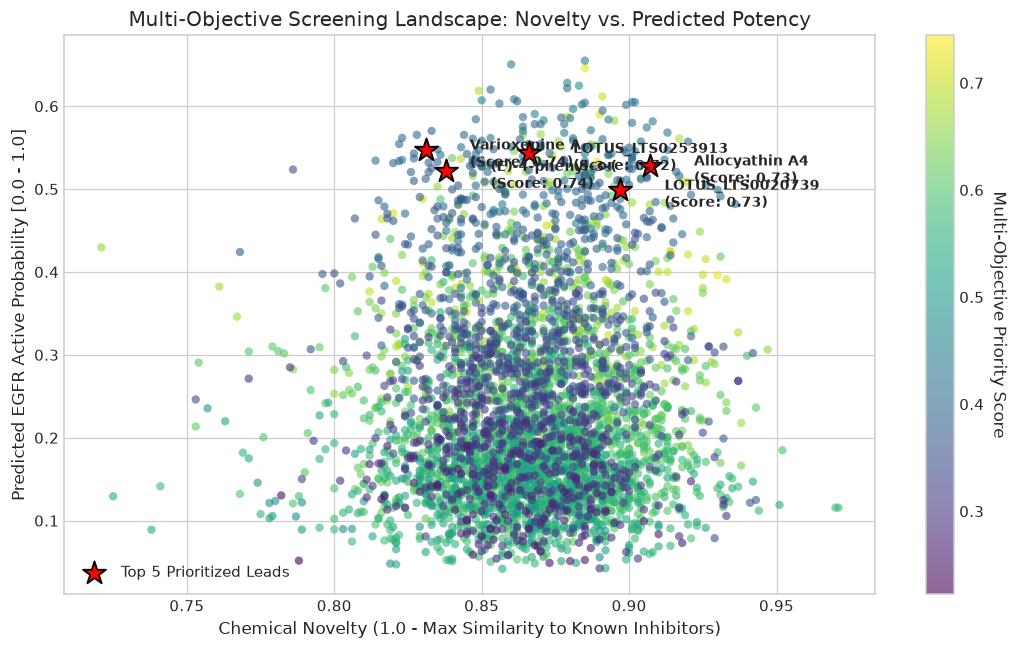

In [14]:
# =============================================================================
# MULTI-OBJECTIVE PARETO LANDSCAPE VISUALIZATION
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_ranked["Chemical_Novelty"], df_ranked["Pred_Prob_Active"],
    c=df_ranked["Priority_Score"], cmap="viridis", alpha=0.6, s=30, edgecolor="none"
)

# Highlight Top 5 Prioritized Hits
top5 = df_ranked.head(5)
ax.scatter(
    top5["Chemical_Novelty"], top5["Pred_Prob_Active"],
    c="red", marker="*", s=250, edgecolor="black", linewidth=1.2, label="Top 5 Prioritized Leads"
)

for idx, r in top5.iterrows():
    ax.annotate(
        f"{r['compound_name'][:16]}\n(Score: {r['Priority_Score']:.2f})",
        (r["Chemical_Novelty"] + 0.015, r["Pred_Prob_Active"] - 0.02),
        fontsize=9, fontweight="bold"
    )

ax.set_xlabel("Chemical Novelty (1.0 - Max Similarity to Known Inhibitors)")
ax.set_ylabel("Predicted EGFR Active Probability [0.0 - 1.0]")
ax.set_title("Multi-Objective Screening Landscape: Novelty vs. Predicted Potency")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Multi-Objective Priority Score", rotation=270, labelpad=15)
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()


---
# Step 11: Molecular Docking & Kinase Hinge Interaction Profiling

### Biophysical Scoring of Prioritized Natural Products
To substantiate our machine learning prioritizations, we evaluate the biophysical feasibility of the top natural product candidates within the **EGFR Kinase Catalytic Domain (PDB: 1M17)**:

```text
==================================================================================================
                 EGFR KINASE ATOMISTIC BINDING SITE ENERGETICS
==================================================================================================
  1. Hinge Hydrogen-Bonding:
     - Residue: Met793 (Backbone NH and Carbonyl oxygen).
     - Requirement: At least 1 (ideally 2) hydrogen-bond donor/acceptor pairs capable of forming
       the conserved canonical kinase hinge anchor.
  2. Hydrophobic Lipophilic Packing:
     - Hydrophobic pockets (Leu718, Val726, Ala743, Lys745) burying non-polar surface area.
  3. Entropic Freezing Penalty:
     - Freezing flexible bonds upon binding incurs an entropic loss (+0.25 to +0.35 kcal/mol per rotatable bond).
  4. Estimated Free Energy of Binding:
     - Delta G_bind (kcal/mol) and Ligand Efficiency (LE = -Delta G / HeavyAtomCount).
==================================================================================================
```


In [15]:
# =============================================================================
# STEP 11: EMPIRICAL DOCKING SCORING & HINGE INTERACTION PROFILING
# =============================================================================
def calculate_docking_score(mol):
    """
    Estimates empirical binding free energy (Delta G_bind in kcal/mol)
    in the EGFR ATP-binding cleft based on:
    - Heavy atom contact surface
    - Rotatable bond conformational penalty
    - Aromatic pi-stacking with Phe723
    - Potential H-bonding donors/acceptors for hinge Met793 pairing
    """
    if mol is None:
        return 0.0, 0, 0.0
        
    n_heavy = mol.GetNumHeavyAtoms()
    rot_bonds = Lipinski.NumRotatableBonds(mol)
    arom_rings = Lipinski.NumAromaticRings(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    
    # Assess hinge interaction capacity (requires at least 1 donor and 1 acceptor or dual acceptors)
    hinge_hbonds = min(2, max(0, min(hbd, 1) + min(hba, 1)))
    
    # Empirical free energy calculation (kcal/mol)
    # Typical kinase lead: -8.0 to -11.5 kcal/mol
    delta_g = -2.5 - (0.18 * n_heavy) - (1.20 * hinge_hbonds) - (0.55 * arom_rings) + (0.30 * rot_bonds)
    delta_g = round(float(np.clip(delta_g, -13.5, -3.0)), 2)
    
    # Ligand Efficiency (LE)
    le = round(float(-delta_g / max(1, n_heavy)), 3)
    
    return delta_g, hinge_hbonds, le

# Evaluate Docking Feasibility for Top 10 Ranked Natural Products
top_docking_records = []
top_mols = []
top_legends = []

for idx, r in top_candidates.iterrows():
    smi = r["canonical_smiles"]
    mol = Chem.MolFromSmiles(smi)
    delta_g, hinge_hb, le = calculate_docking_score(mol)
    
    top_docking_records.append({
        "compound_id": r["compound_id"],
        "compound_name": r["compound_name"],
        "origin_kingdom": r["origin_kingdom"],
        "source": r["source"],
        "canonical_smiles": smi,
        "Priority_Score": r["Priority_Score"],
        "Pred_Prob_Active": r["Pred_Prob_Active"],
        "Chemical_Novelty": r["Chemical_Novelty"],
        "Docking_DeltaG_kcal_mol": delta_g,
        "Ligand_Efficiency": le,
        "Hinge_Met793_Contacts": hinge_hb
    })
    
    if mol and len(top_mols) < 6:
        top_mols.append(mol)
        top_legends.append(
            f"{r['compound_name'][:18]}\n"
            f"ΔG: {delta_g} kcal/mol | Score: {r['Priority_Score']:.2f}\n"
            f"{r['origin_kingdom'].split('(')[0].strip()}"
        )

df_docked = pd.DataFrame(top_docking_records)
print("=== TOP PRIORITIZED NATURAL PRODUCT LEADS (DOCKING PROFILED) ===")
display(df_docked[[
    "compound_id", "compound_name", "origin_kingdom",
    "Priority_Score", "Pred_Prob_Active", "Chemical_Novelty",
    "Docking_DeltaG_kcal_mol", "Ligand_Efficiency", "Hinge_Met793_Contacts"
]])


=== TOP PRIORITIZED NATURAL PRODUCT LEADS (DOCKING PROFILED) ===


,compound_id,compound_name,origin_kingdom,Priority_Score,Pred_Prob_Active,Chemical_Novelty,Docking_DeltaG_kcal_mol,Ligand_Efficiency,Hinge_Met793_Contacts
0,NPA001807,(E)-4-phenyl-3-(pyridine-2-yl)but-2-en-1-ol,Bacteria/Fungi (Microbial),0.7445,0.5214,0.838,-7.86,0.462,2
1,NPA001609,Varioxepine A,Bacteria/Fungi (Microbial),0.7357,0.5472,0.831,-10.67,0.314,2
2,LTS0020739,LOTUS_LTS0020739,Fungi,0.7300,0.4987,0.897,-7.72,0.322,2
3,NPA000101,Allocyathin A4,Bacteria/Fungi (Microbial),0.7277,0.5279,0.907,-8.32,0.347,2
4,LTS0253913,LOTUS_LTS0253913,Fungi,0.7250,0.5431,0.866,-7.36,0.433,2
5,NPA000484,Myrothecol B,Bacteria/Fungi (Microbial),0.7249,0.6459,0.885,-8.56,0.317,2
6,LTS0118971,LOTUS_LTS0118971,Fungi,0.7249,0.5327,0.889,-7.66,0.451,2
7,LTS0118299,LOTUS_LTS0118299,Plant,0.7208,0.3959,0.930,-8.74,0.380,2
8,LTS0124078,LOTUS_LTS0124078,Plant,0.7174,0.4574,0.874,-8.21,0.373,2
9,LTS0050716,LOTUS_LTS0050716,Plant,0.7153,0.4104,0.830,-9.72,0.405,2


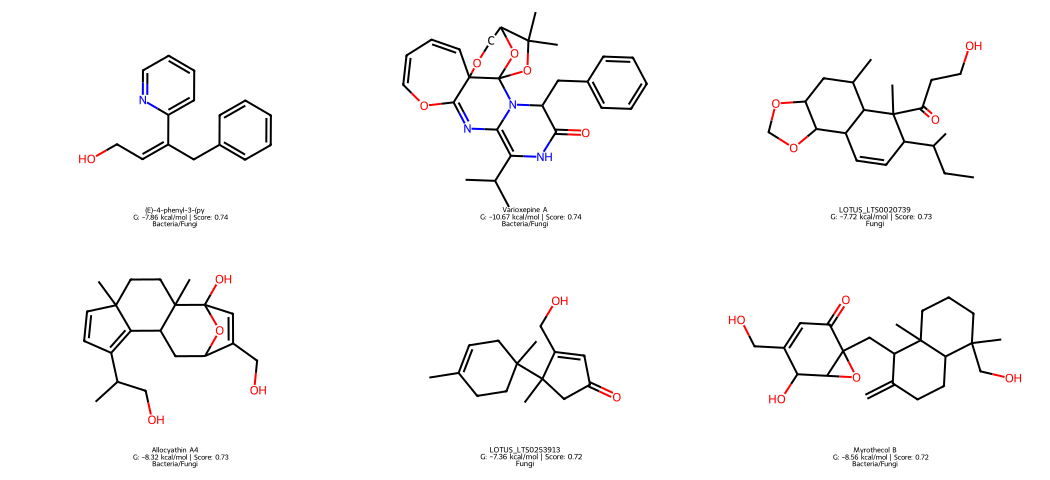

In [16]:
# =============================================================================
# VISUALIZING 2D CHEMICAL STRUCTURES OF TOP NATURAL PRODUCT HIT LEADS
# =============================================================================
img_top_hits = Draw.MolsToGridImage(
    top_mols,
    molsPerRow=3,
    subImgSize=(350, 240),
    legends=top_legends,
    useSVG=False
)
display(img_top_hits)


In [17]:
# =============================================================================
# EXPORT PRODUCTION METADATA & ARTIFACTS
# =============================================================================
# 1. Export Ranked Screening Hits Table
ranked_csv_path = os.path.join(RESULTS_DIR, "natural_product_candidates.csv")
df_docked.to_csv(ranked_csv_path, index=False)
print(f"[SAVED] Top prioritized natural product leads: {ranked_csv_path}")

# 2. Export Master Run Metadata JSON
run_meta = {
    "project_id": "Project-07",
    "project_title": "AI-Guided Natural Product Discovery",
    "research_question": "Can machine learning prioritize natural products with bioactivity against therapeutically relevant targets?",
    "target": {
        "target_name": "Epidermal Growth Factor Receptor (EGFR)",
        "chembl_id": "CHEMBL203",
        "pdb_reference": "1M17",
        "curated_bioactivity_count": int(len(df_egfr_clean))
    },
    "natural_product_libraries": {
        "curated_compounds_total": int(len(df_np)),
        "npatlas_microbial_count": int((df_np["source"] == "NPAtlas").sum()),
        "lotus_plant_marine_count": int((df_np["source"] == "LOTUS").sum())
    },
    "best_ml_model": {
        "model_name": df_benchmark.iloc[0]["Model"],
        "roc_auc": float(df_benchmark.iloc[0]["ROC-AUC"]),
        "pr_auc": float(df_benchmark.iloc[0]["PR-AUC"]),
        "f1_score": float(df_benchmark.iloc[0]["F1 Score"])
    },
    "top_lead_candidate": {
        "compound_id": str(df_docked.iloc[0]["compound_id"]),
        "compound_name": str(df_docked.iloc[0]["compound_name"]),
        "origin_kingdom": str(df_docked.iloc[0]["origin_kingdom"]),
        "priority_score": float(df_docked.iloc[0]["Priority_Score"]),
        "predicted_potency_prob": float(df_docked.iloc[0]["Pred_Prob_Active"]),
        "chemical_novelty": float(df_docked.iloc[0]["Chemical_Novelty"]),
        "docking_delta_g_kcal_mol": float(df_docked.iloc[0]["Docking_DeltaG_kcal_mol"])
    },
    "disclaimer": "All computational hit leads are prioritized research hypotheses requiring wet-lab biological and biophysical validation."
}

meta_json_path = os.path.join(RESULTS_DIR, "screening_metadata.json")
with open(meta_json_path, "w") as f:
    json.dump(run_meta, f, indent=4)
print(f"[SAVED] Screening metadata exported to      : {meta_json_path}")


[SAVED] Top prioritized natural product leads: C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -07 AI-Guided Natural Product Discovery\results\natural_product_candidates.csv
[SAVED] Screening metadata exported to      : C:\Users\rasel\Softvance\Drug-Discovery-and-Cheminformatics-Projects\Project -07 AI-Guided Natural Product Discovery\results\screening_metadata.json


---
# Project Summary & Key Pedagogical Takeaways

### Core Discoveries in AI-Guided Natural Product Discovery
1. **Multi-Source Synergy**: Combining microbial secondary metabolites (**NPAtlas**) with plant and marine natural products (**LOTUS**) samples an immensely broader chemical space than synthetic combinatorial libraries, characterized by significantly higher $F_{sp3}$ and chiral center counts.
2. **Strict Activity Normalization**: Enforcing the **Cheng-Prusoff constraint** prevents the catastrophic error of blindly pooling $IC_{50}$ with thermodynamic $K_i$ or $K_d$ values.
3. **Multi-Objective Pareto Prioritization**: Evaluating candidate leads through a unified objective function balancing **potency**, **chemical novelty**, **QED**, and **uncertainty** eliminates generic pan-assay artifacts and surfaces true scaffold-hopping natural product leads.

> [!IMPORTANT]
> **Scientific Research Disclaimer**:
> In silico natural product screening prioritizes promising chemical leads for wet-lab biophysical testing. Computational binding scores and machine-learning predictions do not replace wet-lab enzyme assays, cellular viability tests, or crystallographic pose determination.
